# 主成分分析：国の生活・経済指標を2次元で可視化する

このNotebookでは、国ごとの生活・経済に関するデータを使って、主成分分析（PCA）を実践する。

主成分分析は、たくさんの変数を少ない変数にまとめるための手法である。  
今回は、GDP、平均寿命、教育指数、インターネット普及率、出生率など複数の指標を使い、国ごとの特徴を2次元のグラフで可視化する。

目的は、複数の指標をまとめて見たときに、国同士がどのように似ているか、またどのように違うかを直感的に理解することである。

## Principal Component Analysis: Visualizing country features from lifestyle and economic indicators

In this notebook, Principal Component Analysis is applied to country-level lifestyle and economic indicators.

PCA is a method used to summarize many variables into a smaller number of new variables called principal components.  
In this analysis, several indicators such as GDP per capita, life expectancy, education index, internet usage, and birth rate are used to visualize country characteristics in two dimensions.

The goal is to understand similarities and differences between countries visually.

## 分析の流れ

このNotebookでは、以下の流れで分析を行う。

1. データを読み込む
2. PCAに使う数値カラムを選ぶ
3. 変数のスケールをそろえるために標準化する
4. PCAを実行して、データを2次元に圧縮する
5. 寄与率を確認する
6. 主成分負荷量を確認する
7. 散布図で国ごとの特徴を可視化する
8. 結果を考察する

## Analysis Flow

This Notebook will perform the analysis in the following steps:

1. Load the data
2. Select the numerical columns to use for PCA
3. Standardize the variables to ensure consistent scales
4. Perform PCA to compress the data into two dimensions
5. Check the contribution rates
6. Check the principal component loadings
7. Visualize country-specific characteristics using a scatter plot
8. Discuss the results

In [1]:
## データ読み込み
## Data Loading
import pandas as pd
from pathlib import Path

BASE_DIR = Path(r"E:\Analytics\Multivariate-Analytics")
df = pd.read_csv(BASE_DIR / "02_pca" / "data" / "country_lifestyle_pca.csv")

df.head()

,country,region,gdp_per_capita,life_expectancy,education_index,internet_users,urban_population,co2_per_capita,birth_rate,unemployment_rate,happiness_score
0,Japan,Asia,42000,84.6,0.85,92,92,8.5,1.3,2.6,6.1
1,United States,North America,76000,77.5,0.90,91,83,14.7,1.7,3.7,6.9
2,Germany,Europe,56000,81.3,0.91,93,78,8.1,1.5,3.1,7.0
3,France,Europe,49000,82.5,0.89,86,81,4.6,1.8,7.3,6.7
4,Brazil,South America,15000,75.9,0.70,81,87,2.2,1.6,8.5,6.1


## データの確認

まず、読み込んだデータを確認する。

このデータでは、1行が1つの国を表している。  
各カラムには、GDP、平均寿命、教育指数、インターネット普及率など、国の特徴を表す数値が入っている。

PCAでは、文字列データではなく数値データを使うため、`country` や `region` は分析対象から外し、数値カラムだけを使用する。

## Data Verification

First, verify the loaded data.

In this data, each row represents one country.

Each column contains numerical values ​​that represent the characteristics of the country, such as GDP, life expectancy, education index, and internet penetration rate.

Since PCA uses numerical data rather than string data, we will exclude `country` and `region` from the analysis and use only the numerical columns.

In [9]:
## データ確認
## Data Check

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            20 non-null     str    
 1   region             20 non-null     str    
 2   gdp_per_capita     20 non-null     int64  
 3   life_expectancy    20 non-null     float64
 4   education_index    20 non-null     float64
 5   internet_users     20 non-null     int64  
 6   urban_population   20 non-null     int64  
 7   co2_per_capita     20 non-null     float64
 8   birth_rate         20 non-null     float64
 9   unemployment_rate  20 non-null     float64
 10  happiness_score    20 non-null     float64
dtypes: float64(6), int64(3), str(2)
memory usage: 1.8 KB


In [10]:
## 基本統計量の確認
## Descriptive Statistics

df.describe()

,gdp_per_capita,life_expectancy,education_index,internet_users,urban_population,co2_per_capita,birth_rate,unemployment_rate,happiness_score
count,20.000000,20.00000,20.000000,20.000000,20.00000,20.000000,20.000000,20.000000,20.000000
mean,38650.000000,76.49500,0.788500,82.650000,74.80000,7.420000,1.930000,6.490000,6.055000
std,24826.291242,7.52431,0.132119,16.368375,16.06762,5.050023,0.913121,6.273327,0.968708
min,6000.000000,54.70000,0.500000,42.000000,36.00000,0.700000,0.800000,2.600000,4.100000
25%,15000.000000,72.25000,0.695000,74.250000,67.25000,3.175000,1.500000,3.625000,5.525000
50%,38000.000000,77.20000,0.815000,87.500000,81.00000,7.550000,1.650000,5.200000,6.100000
75%,57500.000000,82.80000,0.902500,96.000000,84.50000,11.050000,2.050000,7.225000,6.925000
max,89000.000000,84.60000,0.940000,100.000000,92.00000,17.000000,5.200000,32.000000,7.400000


## PCAに使う変数を選ぶ

今回のPCAでは、国の特徴を表す数値カラムを使用する。

`country` は国名、`region` は地域名なので、PCAの計算には使わない。  
PCAでは、複数の数値変数をまとめて、新しい軸である主成分を作る。

## Selecting Variables for PCA

In this PCA analysis, we will use numerical columns that represent the characteristics of each country.

`country` is the country name, and `region` is the region name, so these will not be used in the PCA calculation.

PCA combines multiple numerical variables to create a new axis called the principal component.

In [2]:
## 変数設定
## Variable Setting
features = [
    "gdp_per_capita",
    "life_expectancy",
    "education_index",
    "internet_users",
    "urban_population",
    "co2_per_capita",
    "birth_rate",
    "unemployment_rate",
    "happiness_score"
]

X = df[features]

## 標準化

PCAを行う前に、データを標準化する。

標準化とは、平均が0、標準偏差が1になるようにデータを変換することである。

今回のデータでは、GDPは数万単位、教育指数は0から1程度、出生率は1から5程度と、カラムごとに数値の大きさが大きく異なる。  
そのままPCAを行うと、数値の大きいGDPなどの影響が強くなりすぎる可能性がある。

そのため、PCAの前処理として標準化を行う。

## Standardization

Before performing PCA, the data must be standardized.

Standardization is the process of transforming data so that the mean is 0 and the standard deviation is 1.

In this data, the magnitude of the values ​​varies greatly from column to column: GDP is in the tens of thousands, the education index is around 0 to 1, and the birth rate is around 1 to 5.

Performing PCA directly might lead to an overemphasis on the influence of large values ​​like GDP.

Therefore, standardization is performed as a preprocessing step for PCA.

In [3]:
## 標準化
## Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 0.13844305,  1.10515846,  0.47758078,  0.58606293,  1.09828508,
         0.21941613, -0.70786517, -0.63619445,  0.04766043],
       [ 1.54353669,  0.13703692,  0.86585783,  0.52338241,  0.52360103,
         1.47902727, -0.25842697, -0.4562937 ,  0.89495691],
       [ 0.71701102,  0.65518648,  0.94351325,  0.64874346,  0.20433211,
         0.1381509 , -0.48314607, -0.55442138,  1.00086897],
       [ 0.42772704,  0.81881265,  0.78820242,  0.20997977,  0.39589346,
        -0.5729199 , -0.14606742,  0.13247237,  0.68313279],
       [-0.97736661, -0.08113131, -0.68725039, -0.10342287,  0.77901616,
        -1.06051131, -0.37078652,  0.32872772,  0.04766043]])

## PCAの実行

標準化したデータに対してPCAを実行する。

今回は、複数の変数を2つの主成分にまとめる。  
2つにする理由は、散布図として可視化しやすくするためである。

- PC1：第1主成分
- PC2：第2主成分

PC1とPC2は、元の変数を組み合わせて作られる新しい軸である。

## Performing PCA

Perform PCA on the standardized data.

In this case, we will combine multiple variables into two principal components.

The reason for using two components is to make visualization easier as a scatter plot.

- PC1: First Principal Component

- PC2: Second Principal Component

PC1 and PC2 are new axes created by combining the original variables.

In [4]:
## PCA実行
## Execute PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_result,
    columns=["PC1", "PC2"]
)

pca_df["country"] = df["country"]
pca_df["region"] = df["region"]

pca_df.head()

,PC1,PC2,country,region
0,1.628747,-0.352426,Japan,Asia
1,2.203223,0.109468,United States,North America
2,1.820101,-0.416675,Germany,Europe
3,1.085684,-0.046978,France,Europe
4,-0.646359,0.148755,Brazil,South America


## 寄与率の確認

寄与率とは、それぞれの主成分が元データの情報をどれくらい説明しているかを表す指標である。

例えば、PC1の寄与率が大きい場合、PC1だけで元データの特徴をかなり説明できていることになる。  
PC1とPC2の寄与率を足すことで、2次元に圧縮したときに元データの情報をどれくらい残せているかを確認できる。

## Checking the Contribution Rate

The contribution rate is an indicator that shows how well each principal component explains the information of the original data.

For example, if the contribution rate of PC1 is high, it means that PC1 alone can explain a considerable portion of the features of the original data.

By adding the contribution rates of PC1 and PC2, you can check how much of the original data's information is retained when compressed to two dimensions.

In [5]:
## 寄与率の確認
## Explained Variance Ratio
explained_variance = pd.DataFrame({
    "principal_component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_
})

explained_variance

,principal_component,explained_variance_ratio
0,PC1,0.677756
1,PC2,0.104378


In [11]:
## 累積寄与率の確認
## Cumulative Explained Variance Ratio

explained_variance["cumulative_ratio"] = explained_variance["explained_variance_ratio"].cumsum()

explained_variance

,principal_component,explained_variance_ratio,cumulative_ratio
0,PC1,0.677756,0.677756
1,PC2,0.104378,0.782134


## 主成分負荷量の確認

主成分負荷量は、それぞれの元の変数が、PC1やPC2にどのくらい影響しているかを表す。

値が大きいほど、その主成分に強く関係していると考えられる。  
正の値と負の値を見ることで、どの変数が同じ方向に働いているか、反対方向に働いているかを確認できる。

## Checking Principal Component Loadings

Principal component loadings indicate how much each original variable influences PC1 and PC2.

A larger value suggests a stronger influence on that principal component.

By looking at positive and negative values, you can see which variables are acting in the same direction and which are acting in opposite directions.

In [6]:
## 主成分負荷量の確認
## Principal Component Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

loadings

,PC1,PC2
gdp_per_capita,0.356706,-0.023595
life_expectancy,0.363995,-0.157390
education_index,0.394638,0.065260
internet_users,0.386044,0.149446
urban_population,0.335325,0.164720
co2_per_capita,0.276326,0.265866
birth_rate,-0.300060,-0.074917
unemployment_rate,-0.163276,0.917518
happiness_score,0.360563,-0.053008


## PCA結果の可視化

PC1とPC2を使って、各国を2次元の散布図に表示する。

グラフ上で近くにある国は、複数の指標をまとめて見たときに特徴が似ていると考えられる。  
反対に、離れている国は、生活・経済指標の特徴が異なる可能性がある。

## Visualization of PCA Results

Using PC1 and PC2, each country is displayed on a 2D scatter plot.

Countries that are close together on the graph are likely to have similar characteristics when multiple indicators are viewed together.

Conversely, countries that are far apart may have different characteristics in terms of lifestyle and economic indicators.

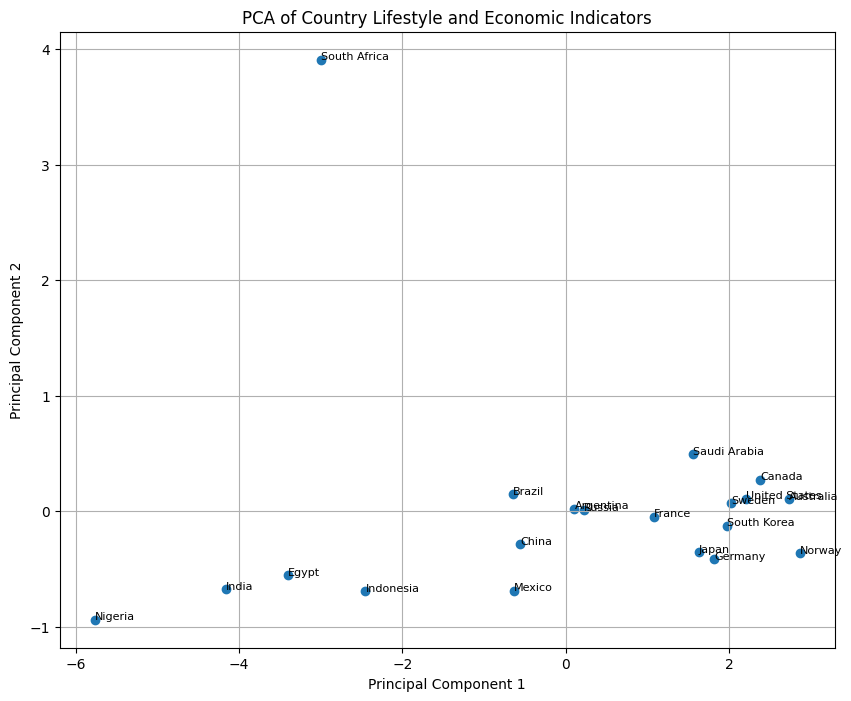

In [7]:
## PCA結果の可視化
## Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(pca_df["PC1"], pca_df["PC2"])

for i, country in enumerate(pca_df["country"]):
    plt.text(
        pca_df["PC1"][i],
        pca_df["PC2"][i],
        country,
        fontsize=8
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Country Lifestyle and Economic Indicators")
plt.grid()
plt.show()

## 考察

PC1は、GDP、平均寿命、教育指数、インターネット普及率、幸福度などの影響を受けているため、国の生活水準や経済発展度を表す軸と考えられる。

PC2は、出生率、失業率、CO2排出量などの影響を受けており、国ごとの社会構造や産業構造の違いを表している可能性がある。

主成分分析を使うことで、複数の指標を2つの軸にまとめ、国ごとの特徴を視覚的に比較できる。

## Discussion

PC1 is influenced by GDP, life expectancy, education index, internet penetration rate, and happiness index, and can therefore be considered an axis representing a country's standard of living and economic development.

PC2 is influenced by birth rate, unemployment rate, and CO2 emissions, and may represent differences in social and industrial structures between countries.

By using principal component analysis, multiple indicators can be combined into two axes, allowing for a visual comparison of the characteristics of each country.

**備考**: 本Notebookで用いたデータセットは、サンプルです

 **Note**: The dataset used in this Notebook is a sample.